In [193]:

# Importing the libraries
import pandas as pd
import numpy as np
import polars as pl
import os
import sys
import altair as alt
import vegafusion as vf
import sklearn
import time
from datetime import date, datetime, timedelta
from sklearn.pipeline import Pipeline, make_pipeline
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import itertools
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.tsa.api as smt


In [194]:
def f_get_data_and_info(import_path, file_name="df_final"):

    print(f"\nReading file {file_name}\n")

    # Load data.
    df = pd.read_parquet(import_path + file_name + ".parquet")

    # Getting the basic information of the dataframe (number of observations and features, and size)
    print(
        f"The '{file_name}' dataframe contains: {df.shape[0]:,}".replace(",", ".")
        + f" observations and {df.shape[1]} features."
    )
    print(
        f"Prepared and transformed dataframe has optimized size of {round(sys.getsizeof(df)/1024/1024/1024, 2)} GB."
    )

    return df

In [195]:
import_path = "/Users/Georgi/Dropbox/Data and AI/Applications/Group Project Datasets/"


# import_path = "C:/Users/sebas/OneDrive/Documenten/GitHub/Supermarketcasegroupproject/Group4B/data/raw/


# Importing final df


# df_test = f_get_data_and_info(import_path, file_name="test_df_20241115")
# df_val = f_get_data_and_info(import_path, file_name="val_df_20241115")
df_train = f_get_data_and_info(import_path, file_name="df_agg")


Reading file df_agg

The 'df_agg' dataframe contains: 8.466.612 observations and 17 features.
Prepared and transformed dataframe has optimized size of 0.32 GB.


In [196]:
# Assuming the DataFrames are named df1, df2, and df3
# num_rows_df1 = df_test.shape[0]  # Number of rows in df1
# num_rows_df2 = df_val.shape[0]  # Number of rows in df2
# num_rows_df3 = df_train.shape[0]  # Number of rows in df3

# Or using len()
#  num_rows_df1 = len(df_test)
# num_rows_df2 = len(df_val)
# num_rows_df3 = len(df_train)

# Print the results
# print(f"Number of observations in df1: {num_rows_df1}")
# print(f"Number of observations in df2: {num_rows_df2}")
# print(f"Number of observations in df3: {num_rows_df3}")

In [197]:
df_train.head()

,store_nbr,item_nbr,year,week_number_cum,unit_sales,onpromotion,holiday_local_count,holiday_regional_count,holiday_national_count,date,store_type,store_cluster,item_family,item_class,perishable,store_status,item_status
0,1,103520,2013,1,5.0,0,0,0,1,2013-01-02,D,13,GROCERY I,1028,0,0,1
1,1,103520,2013,2,15.0,0,0,0,1,2013-01-07,D,13,GROCERY I,1028,0,0,1
2,1,103520,2013,3,10.0,0,0,0,0,2013-01-14,D,13,GROCERY I,1028,0,0,1
3,1,103520,2013,4,23.0,0,0,0,0,2013-01-21,D,13,GROCERY I,1028,0,0,1
4,1,103520,2013,5,10.0,0,0,0,0,2013-01-28,D,13,GROCERY I,1028,0,0,1


In [198]:
selected_item_nbr = 103520  # Replace with the desired item number
selected_store_nbr = 1      # Replace with the desired store number



# Filter the DataFrame
filtered_df = df_train[         (df_train['item_nbr'] == selected_item_nbr) 
                         &    (df_train['store_nbr'] == selected_store_nbr)
                        ]
filtered_df = filtered_df[['date', 'unit_sales', 'week_number_cum']]
df=filtered_df
# Display the filtered DataFrame
print(df)

          date  unit_sales  week_number_cum
0   2013-01-02         5.0                1
1   2013-01-07        15.0                2
2   2013-01-14        10.0                3
3   2013-01-21        23.0                4
4   2013-01-28        10.0                5
..         ...         ...              ...
237 2017-07-17         8.0              238
238 2017-07-24        13.0              239
239 2017-07-31        10.0              240
240 2017-08-07         9.0              241
241 2017-08-14         0.0              242

[242 rows x 3 columns]


In [199]:
# 1. Filter data based on the 'date' range
df_train = df[(filtered_df['week_number_cum'] > 138) & (filtered_df['week_number_cum'] <= 190)]
df_test = df[(df['week_number_cum'] > 190) & (df['week_number_cum'] <= 216)]
df_validate = df[df['week_number_cum'] > 216]

In [200]:
df_train = df_train[['date', 'unit_sales']]
df_test = df_test[['date', 'unit_sales']]
print(df_test)

          date  unit_sales
190 2016-08-22         9.0
191 2016-08-29         4.0
192 2016-09-05         6.0
193 2016-09-12        14.0
194 2016-09-19        17.0
195 2016-09-26        18.0
196 2016-10-03        14.0
197 2016-10-10         7.0
198 2016-10-17        10.0
199 2016-10-24         5.0
200 2016-10-31        12.0
201 2016-11-07        10.0
202 2016-11-14         7.0
203 2016-11-21        10.0
204 2016-11-28        15.0
205 2016-12-05        10.0
206 2016-12-12       111.0
207 2016-12-19        53.0
208 2016-12-26        10.0
209 2017-01-02         9.0
210 2017-01-09         5.0
211 2017-01-16        12.0
212 2017-01-23         6.0
213 2017-01-30         8.0
214 2017-02-06         5.0
215 2017-02-13         9.0


In [201]:
# Ensure the 'date' column is in datetime format and the dataset is sorted by date
df_train['date'] = pd.to_datetime(df_train['date'])
df_test['date'] = pd.to_datetime(df_test['date'])
df_train = df_train.sort_values('date')
df_test = df_test.sort_values('date')


In [229]:
# Step 1: Train the Holt-Winters model with trend and seasonality (triple exponential smoothing)
model = ExponentialSmoothing(
    df_train['unit_sales'],       # The target variable for forecasting
    trend='add',                  # Additive trend (you can use 'multiplicative' as well)
    seasonal='add',               # Additive seasonality (you can use 'multiplicative' as well)
    seasonal_periods=16          # Assuming weekly seasonality (52 weeks in a year)
)
# Step 2: Fit the model
hw_model = model.fit(smoothing_level=0.1
                     , smoothing_trend=0.9
                     , smoothing_seasonal=0.8)




# Step 3: Make predictions on the test dataset
forecast = hw_model.forecast(len(df_test))
df_test.reset_index(drop=True, inplace=True)
forecast.reset_index(drop=True, inplace=True)
# Step 4: Evaluate the forecast (Bias and MAPE)
df_test['forecast'] = forecast
df_test['bias'] = df_test['forecast'] - df_test['unit_sales']
df_test['mape'] = (1-abs(df_test['bias'] / df_test['unit_sales']) )* 100

# Print the first few rows with forecast and error metrics
#print(df_test[['date', 'unit_sales', 'forecast', 'bias', 'mape']].tail())
#df_test.head(20)
df_test.head(15)


/Users/Georgi/Documents/Group4B/venv_case_project/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/Georgi/Documents/Group4B/venv_case_project/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/Georgi/Documents/Group4B/venv_case_project/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


,date,unit_sales,forecast,bias,mape
0,2016-08-22,9.0,15.744779,6.744779,25.058017
1,2016-08-29,4.0,14.008979,10.008979,-150.224468
2,2016-09-05,6.0,11.985972,5.985972,0.233805
3,2016-09-12,14.0,8.526252,-5.473748,60.901798
4,2016-09-19,17.0,10.632636,-6.367364,62.544918
5,2016-09-26,18.0,13.752186,-4.247814,76.401033
6,2016-10-03,14.0,4.837439,-9.162561,34.553133
7,2016-10-10,7.0,5.216821,-1.783179,74.526020
8,2016-10-17,10.0,11.856282,1.856282,81.437179
9,2016-10-24,5.0,4.925631,-0.074369,98.512624


In [230]:
mean_mape = df_test['mape'].mean()
print("Mean of MAPE:", mean_mape)

Mean of MAPE: 33.04167959062779


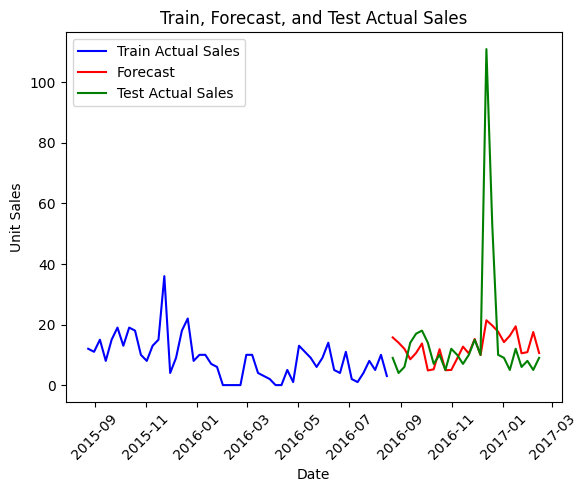

In [235]:
import matplotlib.pyplot as plt

# Plotting the actual unit_sales from the training set
plt.plot(df_train['date'], df_train['unit_sales'], label='Train Actual Sales', color='blue')

# Plotting the forecasted values (for the test period)
# Ensure that the forecast corresponds to the correct time range (same length as the test data)
plt.plot(df_test['date'], forecast, label='Forecast', color='red')

# Plotting the actual unit_sales from the test set
plt.plot(df_test['date'], df_test['unit_sales'], label='Test Actual Sales', color='green')

# Adding labels and title
plt.title('Train, Forecast, and Test Actual Sales')
plt.xlabel('Date')
plt.ylabel('Unit Sales')

# Show legend
plt.legend()

# Rotate date labels for better readability
plt.xticks(rotation=45

# Display the plot
plt.show()
